# VAE evaluation

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import torch
import umap

from data import CLASSES, BreathDataset, load_dataset, split_dataset
from models.vae import VAE, CVAE

plt.rcParams.update({'legend.fontsize': 9,
                     'axes.titlesize': 10})

### VAE

In [19]:
regions = ['mouth', 'nose']
channel_names = ['Humidity in %', 'Temperature in °C']
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"models/checkpoints/vae_{region}.pt"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = VAE(latent_dim=ckpt['latent_dim']).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    models[region] = model

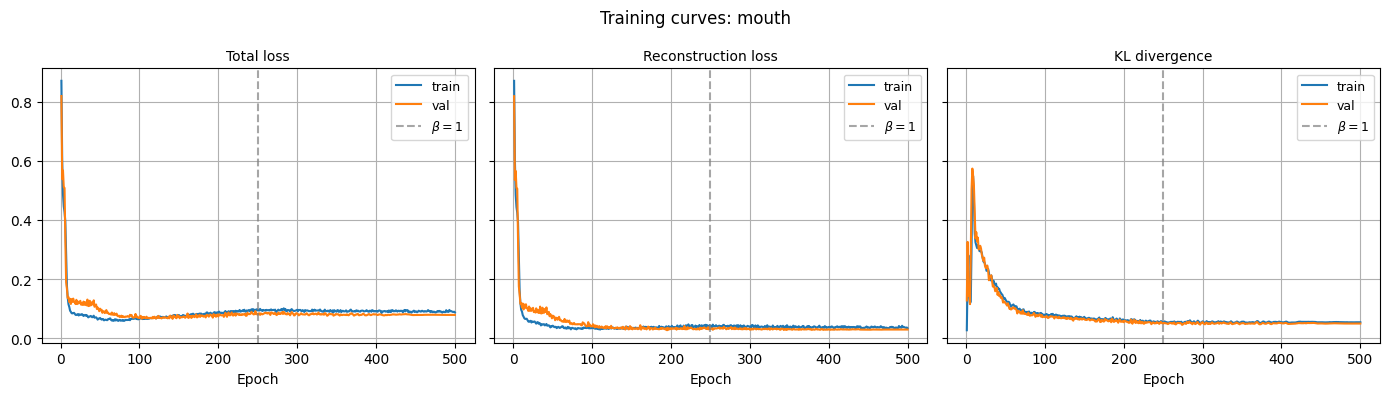

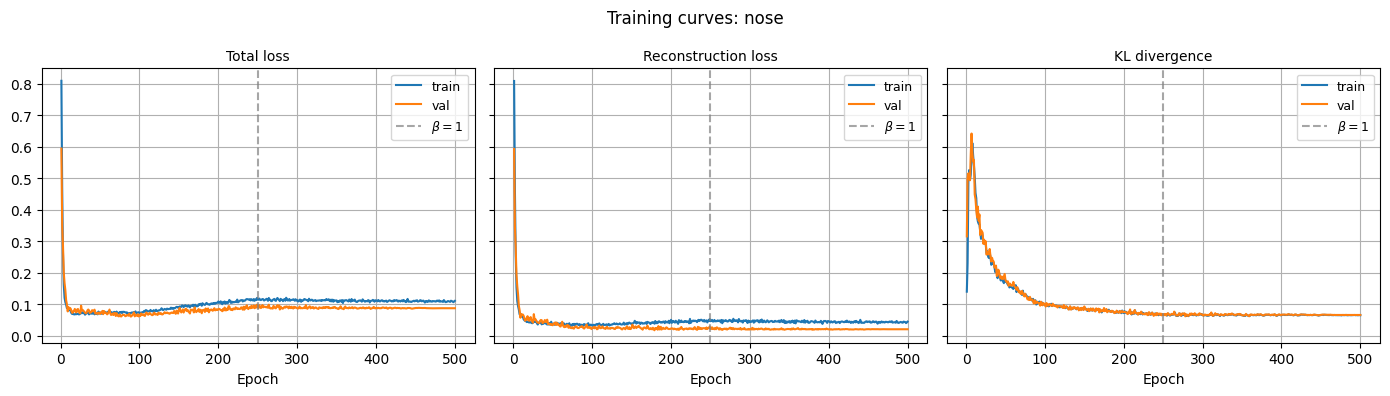

In [20]:
for region in regions:
    path = f'results/vae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

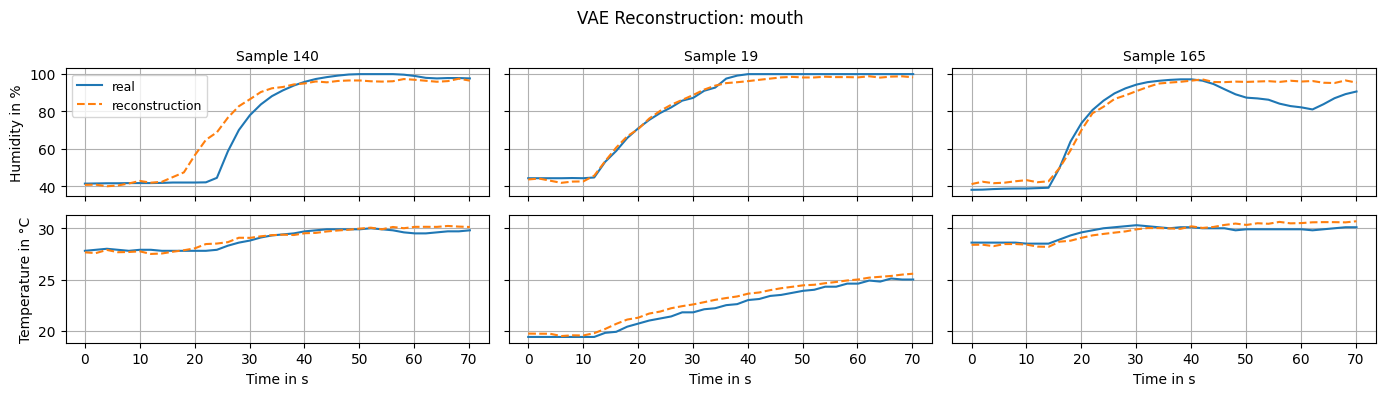

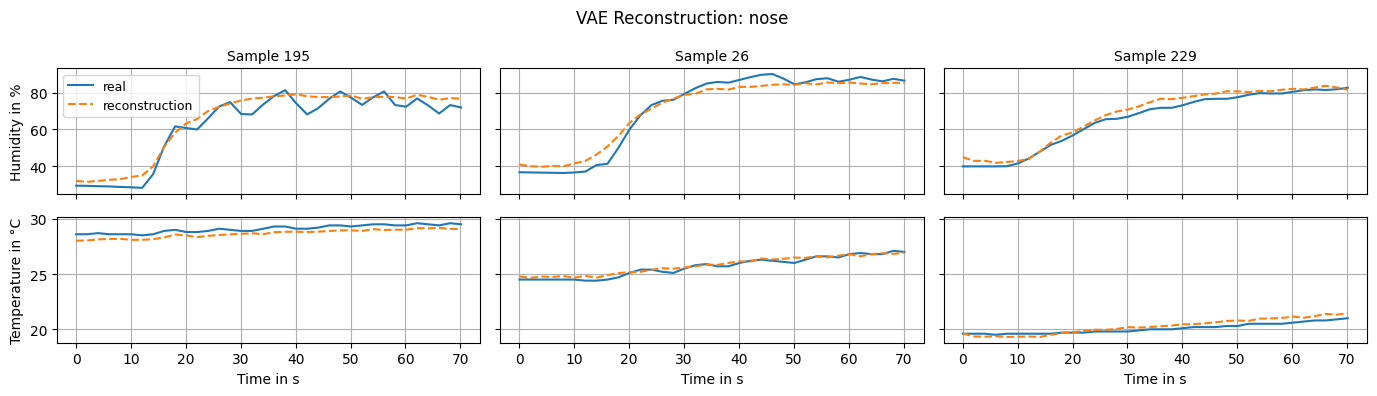

In [21]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'VAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx}')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

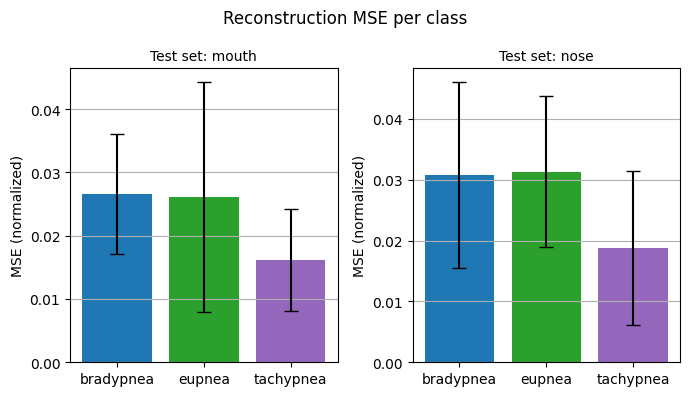

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(regions):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            x_hat, _, _ = model(signal.unsqueeze(0).to(device))
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(class_colors.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

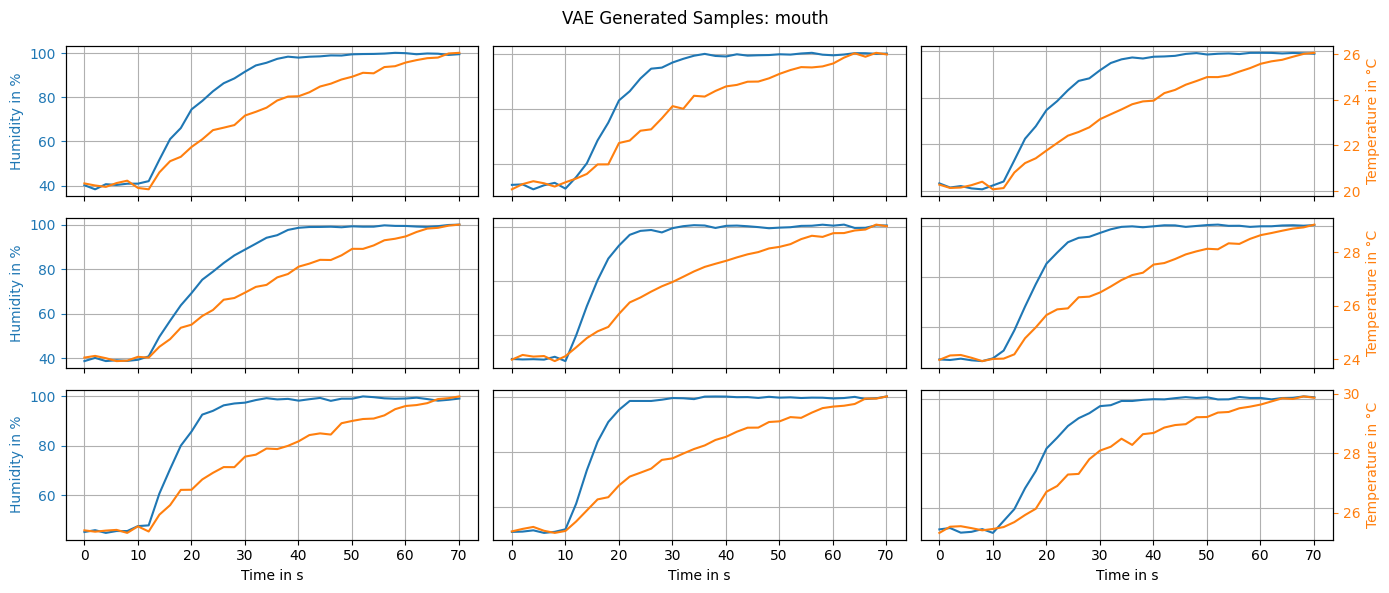

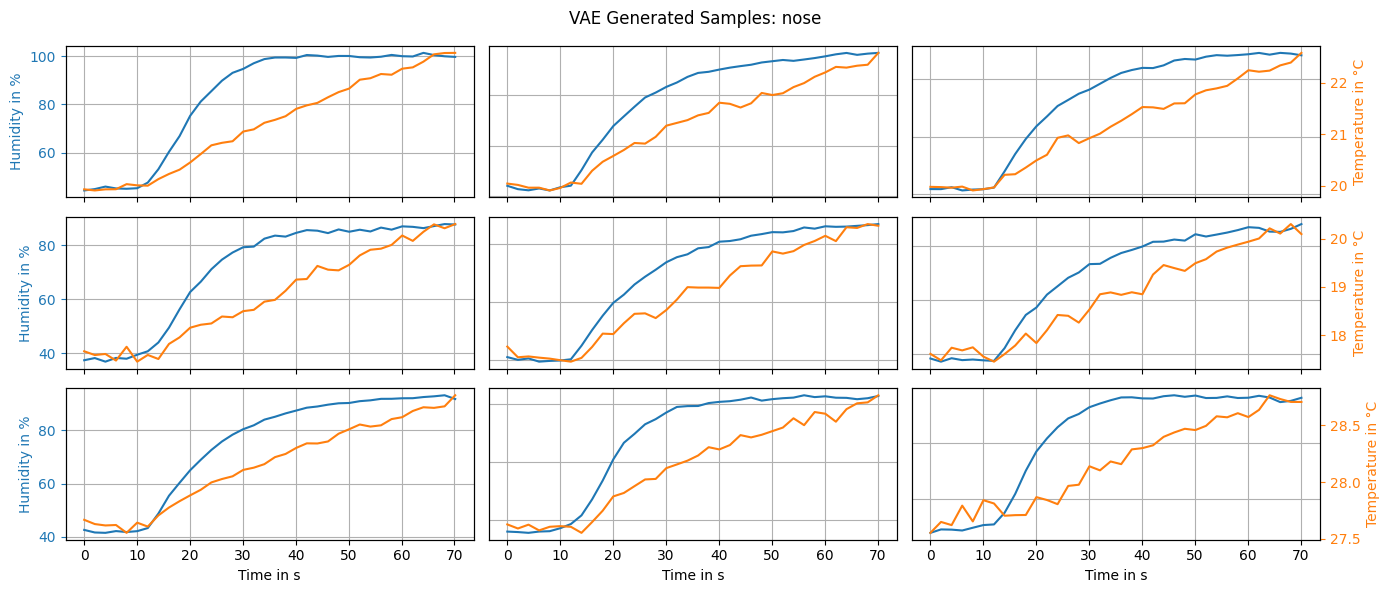

In [23]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()
    
    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean
    
    # plot
    samples  = denorm(model.sample(9, device).cpu().numpy())
    time_np  = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'VAE Generated Samples: {region}')
    for i, ax in enumerate(axes.flatten()):
        row = i // 3
        col = i % 3
        l1, = ax.plot(time_np, samples[i, 0], color='tab:blue', label='Humidity in %')
        ax.grid()
        ax_r = ax.twinx()
        l2, = ax_r.plot(time_np, samples[i, 1], color='tab:orange', label='Temperature in °C')
        if col == 0:
            ax.set_ylabel('Humidity in %', color='tab:blue')
            ax.tick_params(axis='y', colors='tab:blue')
        else:
            ax.set_yticklabels([])
            ax.tick_params(axis='y', length=0)
        if col == 2:
            ax_r.set_ylabel('Temperature in °C', color='tab:orange')
            ax_r.tick_params(axis='y', colors='tab:orange')
        else:
            ax_r.set_yticklabels([])
            ax_r.tick_params(axis='y', length=0)
        if row == 2:
            ax.set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()


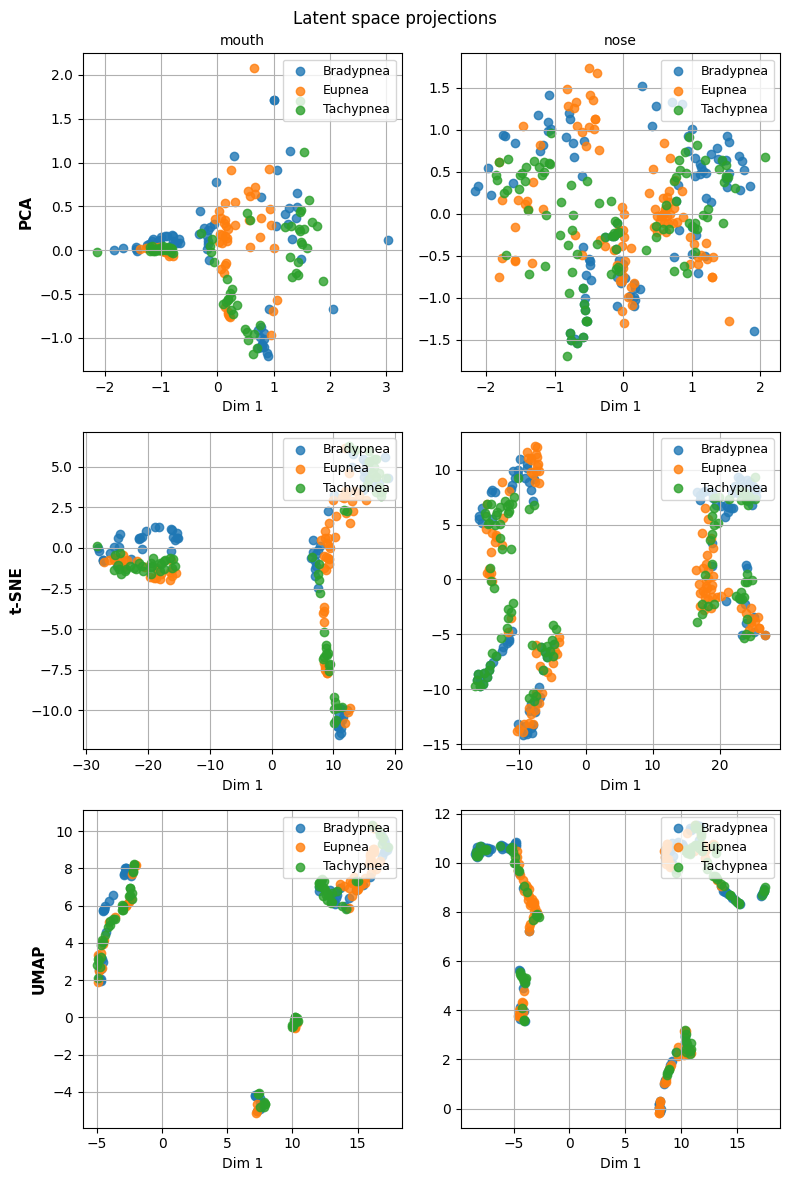

In [24]:
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
plt.suptitle('Latent space projections')

methods = [
    ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
    ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
    ('UMAP',  lambda z: umap.UMAP(n_components=2, random_state=42, n_jobs=1).fit_transform(z)),
]

for col, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)

    for row, (method_name, project) in enumerate(methods):
        z2d = project(mus)
        ax  = axes[row, col]
        for i, cls in enumerate(CLASSES):
            mask = labels == i
            ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Dim 1')
        ax.legend(loc='upper right')
        ax.grid()

plt.tight_layout()
plt.show()

### CVAE

In [25]:
regions = ['mouth', 'nose']
channel_names = ['Humidity in %', 'Temperature in °C']
class_colors = {'bradypnea': 'tab:blue', 'eupnea': 'tab:green', 'tachypnea': 'tab:purple'}
device = torch.device('cuda' if torch.cuda.is_available() else
                      'mps' if torch.backends.mps.is_available() else 'cpu')
models = {} 
datasets = {}
splits = {}

for region in regions:
    # load dataset
    df = load_dataset()
    df = df[df["region"] == region].reset_index(drop=True)
    df_train, df_val, df_test = split_dataset(df, random_state=42)

    # datasets
    train_ds = BreathDataset(df_train)
    val_ds = BreathDataset(df_val,  stats=train_ds.stats)
    test_ds = BreathDataset(df_test, stats=train_ds.stats)
    datasets[region] = {"train": train_ds, "val": val_ds, "test": test_ds}
    splits[region] = {"train": df_train, "val": df_val, "test": df_test}

    # model
    ckpt_path = f"models/checkpoints/cvae_{region}.pt"
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = CVAE(latent_dim=ckpt['latent_dim'], embed_dim=ckpt['embed_dim']).to(device)
    model.load_state_dict(ckpt['model_state'])
    model.eval()

    models[region] = model

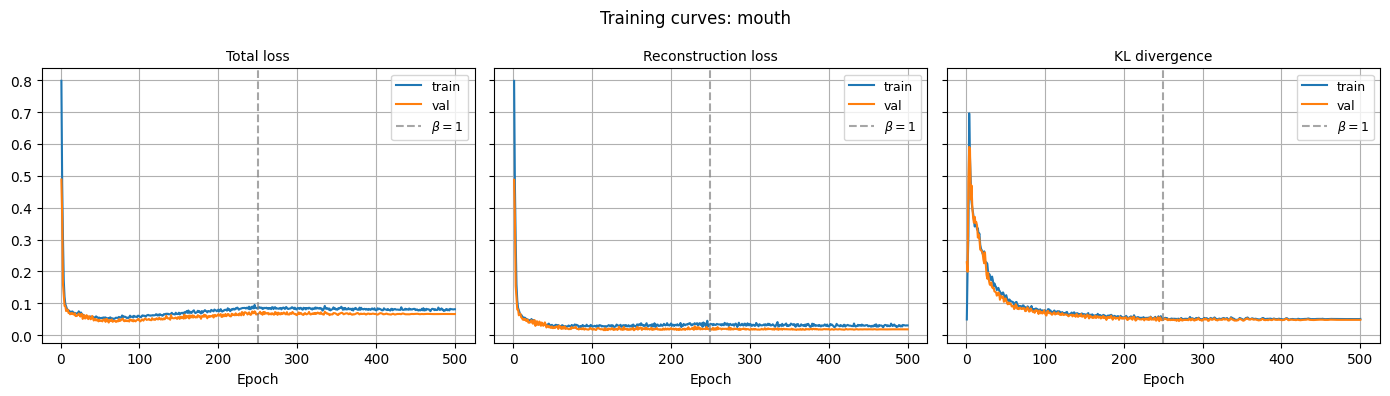

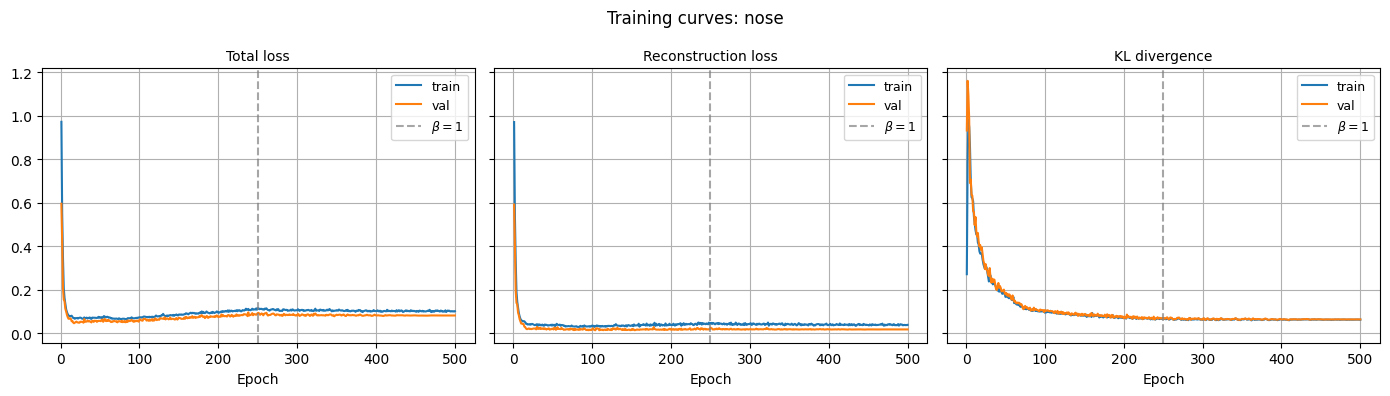

In [26]:
for region in regions:
    path = f'results/cvae/train_{region}.csv'
    hist = pd.read_csv(path)
    beta1_epoch = hist.loc[hist['beta'] >= 1.0, 'epoch'].min()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f'Training curves: {region}')
    pairs = [('train_loss', 'val_loss', 'Total loss'),
            ('train_recon', 'val_recon','Reconstruction loss'),
            ('train_kl', 'val_kl', 'KL divergence')]
    for ax, (tr_col, vl_col, title) in zip(axes, pairs):
        ax.plot(hist['epoch'], hist[tr_col], label='train')
        ax.plot(hist['epoch'], hist[vl_col], label='val')
        ax.axvline(beta1_epoch, color='gray', linestyle='--', alpha=0.7, label=r'$\beta=1$')
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid()
    plt.tight_layout()
    plt.show()

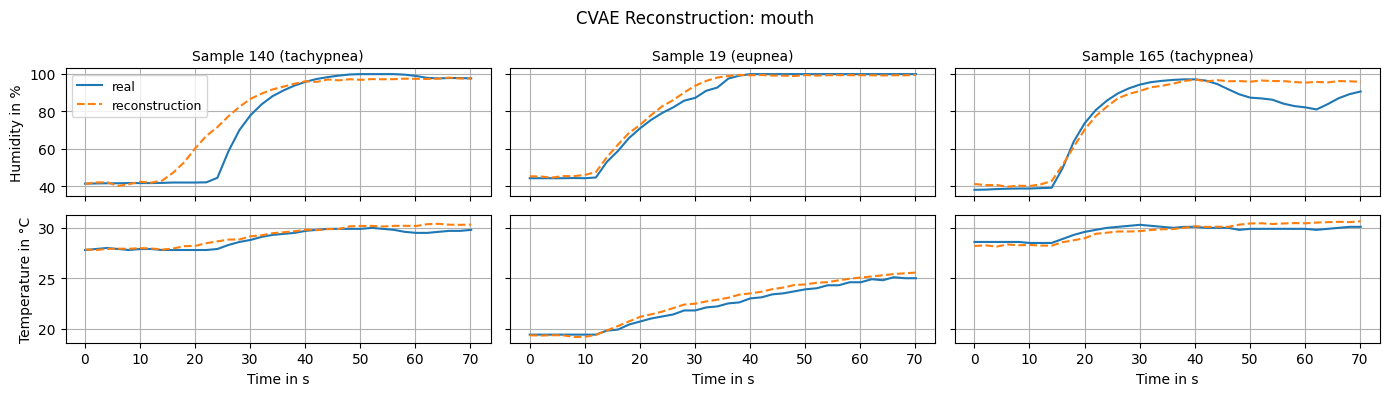

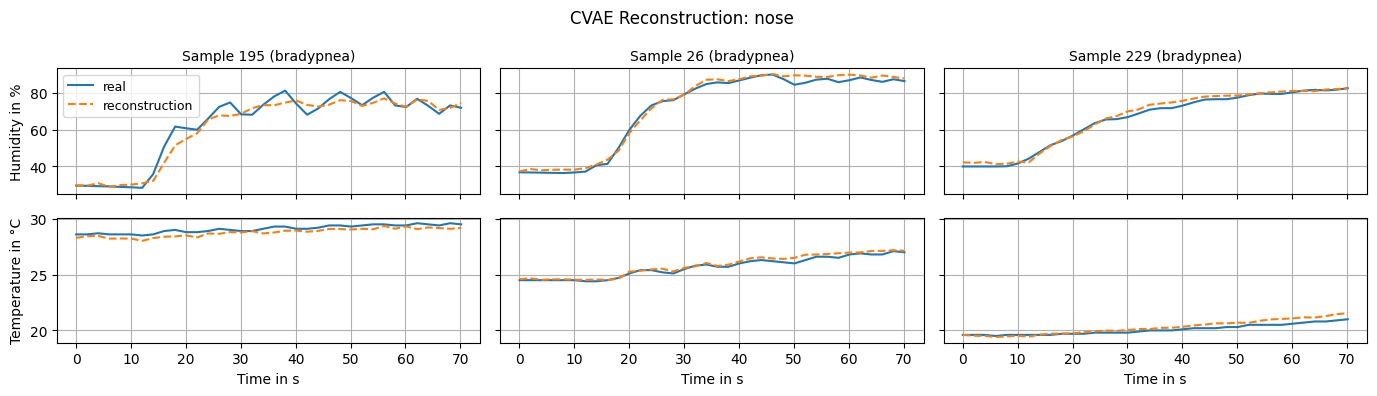

In [27]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    # denormalization
    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    fig, axes = plt.subplots(2, 3, figsize=(14, 4), sharex=True, sharey='row')
    fig.suptitle(f'CVAE Reconstruction: {region}')

    # sample 3 signals from train_ds
    sample_indices = np.random.default_rng(42).choice(len(train_ds), size=3, replace=False)
    for col, idx in enumerate(sample_indices):
        signal, time, label = train_ds[idx]
        signal_batch = signal.unsqueeze(0).to(device)
        label_t = torch.tensor([label]).long().to(device)
        with torch.no_grad():
            x_hat, _, _ = model(signal_batch, label_t)
        x_hat      = denorm(x_hat.squeeze(0).cpu().numpy())
        signal_np  = denorm(signal.numpy())
        time_np    = time.numpy()

        for row in range(2):
            ax = axes[row, col]
            ax.plot(time_np, signal_np[row], label='real', color='tab:blue')
            ax.plot(time_np, x_hat[row], label='reconstruction', color='tab:orange', linestyle='--')
            ax.grid()
            axes[row, 0].set_ylabel(channel_names[row])
            axes[0, col].set_title(f'Sample {idx} ({CLASSES[label]})')
            axes[0, 0].legend(loc='upper left')
            axes[-1, col].set_xlabel('Time in s')
    plt.tight_layout()
    plt.show()

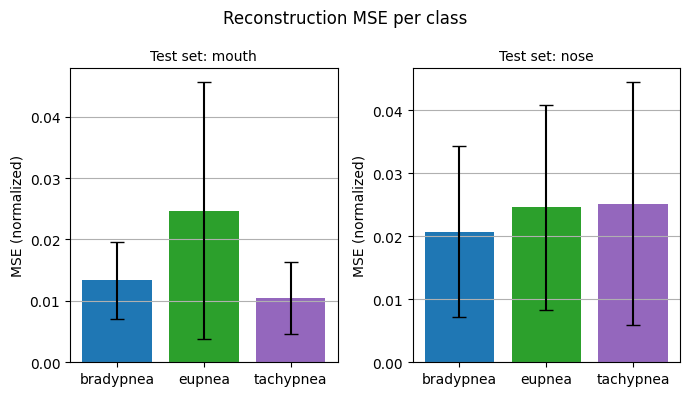

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))
plt.suptitle('Reconstruction MSE per class')
for region_idx, region in enumerate(regions):
    test_ds = datasets[region]['test']
    model = models[region]
    model.eval()

    mse_per_class = {i: [] for i in range(len(CLASSES))}
    with torch.no_grad():
        for i in range(len(test_ds)):
            signal, _, label = test_ds[i]
            label_t = torch.tensor([label]).long().to(device)
            x_hat, _, _ = model(signal.unsqueeze(0).to(device), label_t)
            mse = (x_hat.squeeze(0) - signal.to(device)).pow(2).mean().item()
            mse_per_class[label].append(mse)
    means = [np.mean(mse_per_class[i]) for i in range(len(CLASSES))]
    stds  = [np.std(mse_per_class[i])  for i in range(len(CLASSES))]

    ax = fig.axes[region_idx]
    ax.bar(CLASSES, means, yerr=stds, capsize=5, color=list(class_colors.values()))
    ax.set_ylabel('MSE (normalized)')
    ax.set_title(f'Test set: {region}')
    ax.grid(axis='y')
plt.tight_layout()
plt.show()

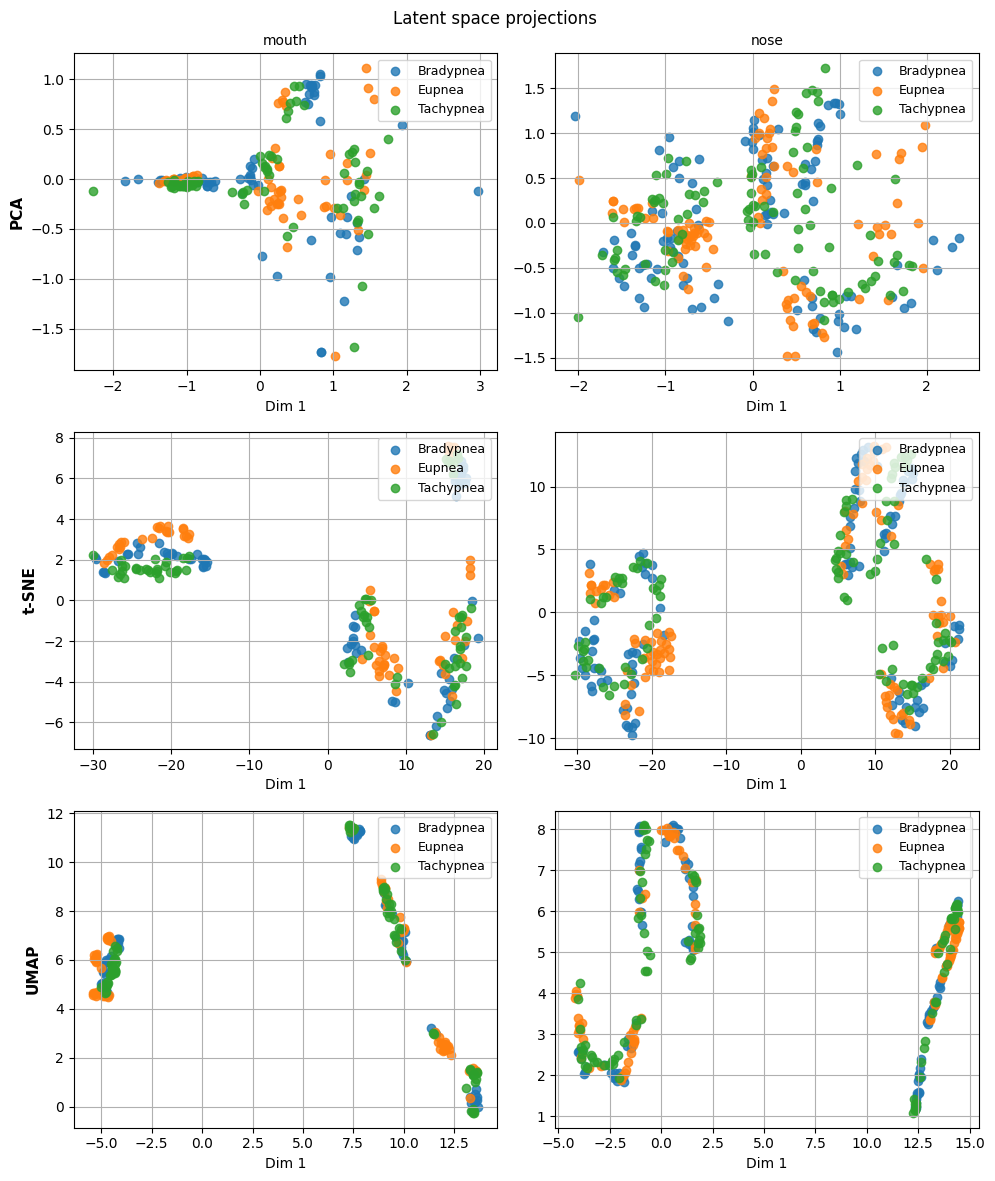

In [34]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
plt.suptitle('Latent space projections')

methods = [
    ('PCA',   lambda z: PCA(n_components=2).fit_transform(z)),
    ('t-SNE', lambda z: TSNE(n_components=2, random_state=42).fit_transform(z)),
    ('UMAP',  lambda z: umap.UMAP(n_components=4, random_state=42, n_jobs=1).fit_transform(z)),
]

for col, region in enumerate(regions):
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mus, labels = [], []
    with torch.no_grad():
        for i in range(len(train_ds)):
            signal, _, label = train_ds[i]
            mu, _ = model.encoder(signal.unsqueeze(0).to(device),
                                  torch.tensor([label]).long().to(device))
            mus.append(mu.squeeze(0).cpu().numpy())
            labels.append(label)
    mus    = np.stack(mus)
    labels = np.array(labels)

    for row, (method_name, project) in enumerate(methods):
        z2d = project(mus)
        ax  = axes[row, col]
        for i, cls in enumerate(CLASSES):
            mask = labels == i
            ax.scatter(z2d[mask, 0], z2d[mask, 1], label=cls.capitalize(), alpha=0.8)
        if row == 0:
            ax.set_title(region)
        if col == 0:
            ax.set_ylabel(method_name, fontsize=11, fontweight='bold')
        ax.set_xlabel('Dim 1')
        ax.legend(loc='upper right')
        ax.grid()

plt.tight_layout()
plt.show()


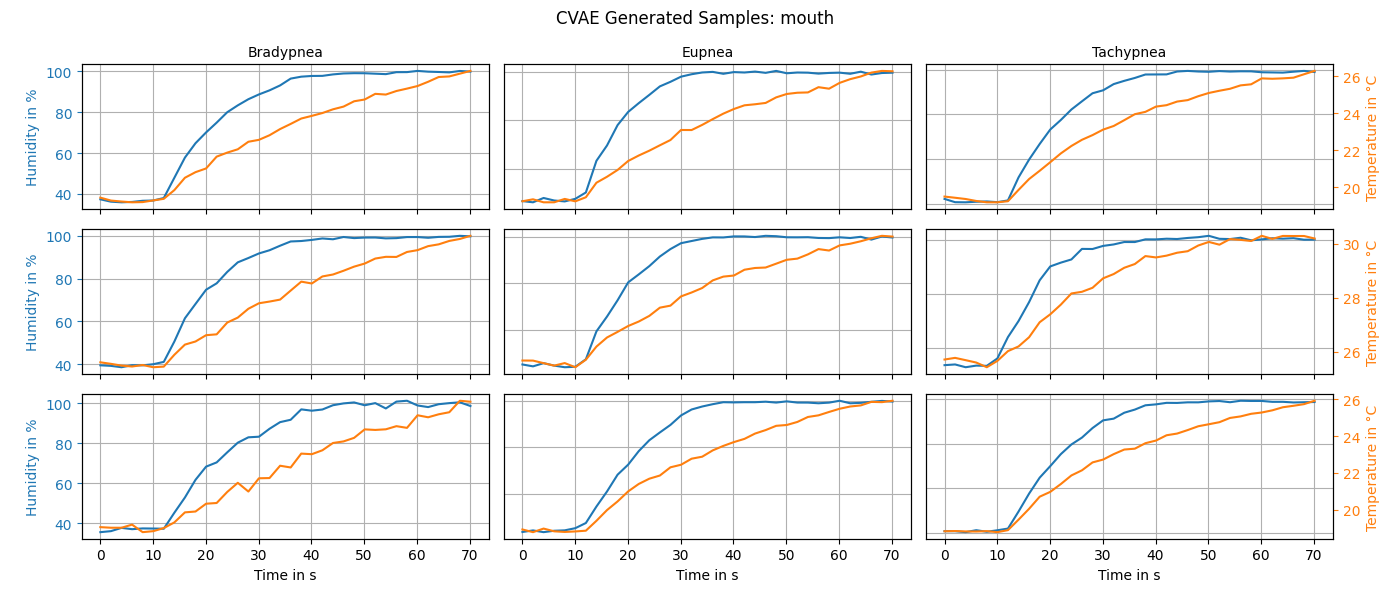

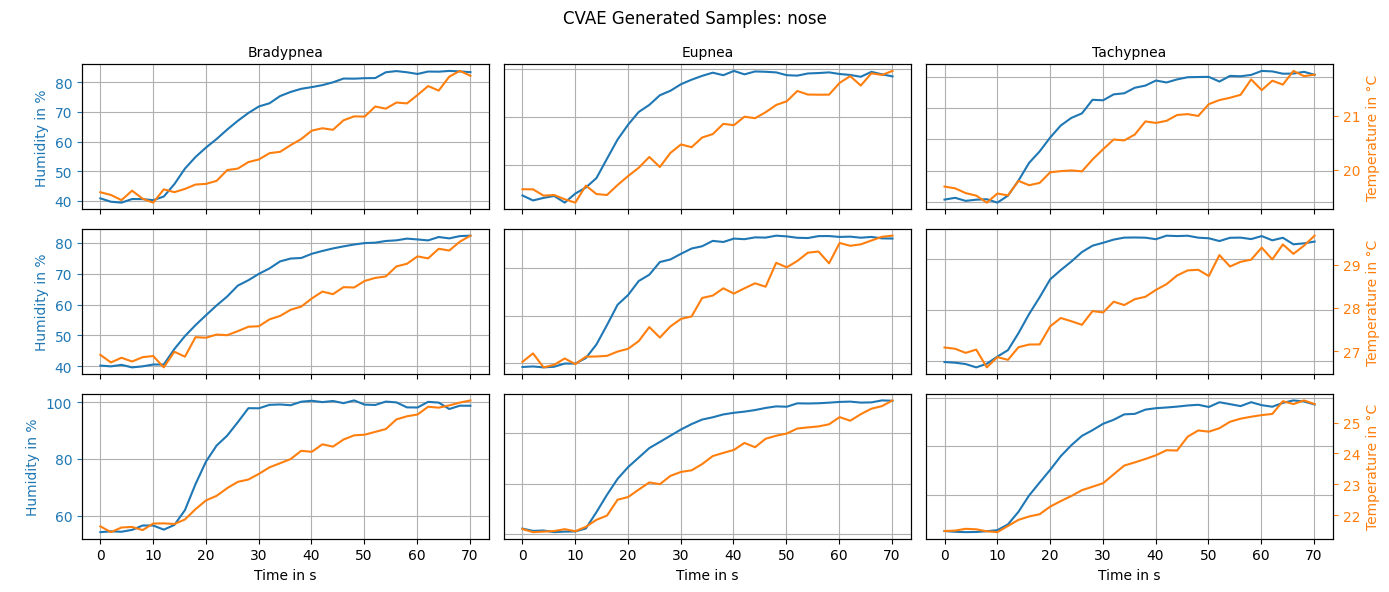

In [30]:
for region in regions:
    train_ds = datasets[region]['train']
    model = models[region]
    model.eval()

    mean = train_ds.stats['mean'][:, None]
    std  = train_ds.stats['std'][:, None]
    def denorm(x):
        return x * std + mean

    time_np = train_ds[0][1].numpy()

    fig, axes = plt.subplots(3, 3, figsize=(14, 6), sharex=True, sharey=False)
    fig.suptitle(f'CVAE Generated Samples: {region}')

    for col, (cls, cls_idx) in enumerate(zip(CLASSES, range(len(CLASSES)))):
        samples = denorm(model.sample(3, torch.tensor(cls_idx).long(), device).cpu().numpy())
        for row in range(3):
            ax = axes[row, col]
            ax.plot(time_np, samples[row, 0], color='tab:blue')
            ax.grid()
            ax_r = ax.twinx()
            ax_r.plot(time_np, samples[row, 1], color='tab:orange')
            if row == 0:
                ax.set_title(f'{cls.capitalize()}')
            if col == 0:
                ax.set_ylabel(f'\n{channel_names[0]}', color='tab:blue')
                ax.tick_params(axis='y', colors='tab:blue')
            else:
                ax.set_yticklabels([])
                ax.tick_params(axis='y', length=0)
            if col == 2:
                ax_r.set_ylabel(channel_names[1], color='tab:orange')
                ax_r.tick_params(axis='y', colors='tab:orange')
            else:
                ax_r.set_yticklabels([])
                ax_r.tick_params(axis='y', length=0)
            if row == 2:
                ax.set_xlabel('Time in s')

    plt.tight_layout()
    plt.show()
